In [1]:
import os
import random
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import csv

# Настройки визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8')

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("artifacts/figures", exist_ok=True)

Using device: cpu


Total observations: 4320
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values:
date      0
target    0
dtype: int64


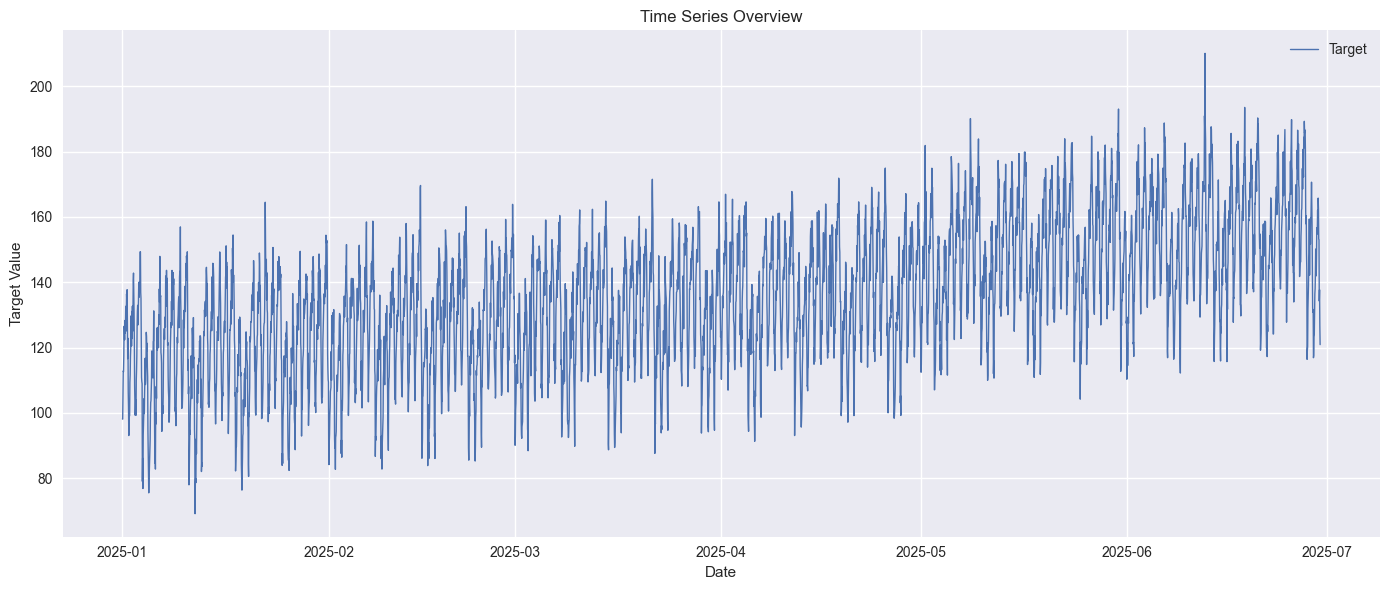

In [2]:
data_path = "S12-hw-dataset.csv"
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], label='Target', linewidth=1)
plt.title('Time Series Overview')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.tight_layout()
plt.show()

Train: 2592 rows
Val:   864 rows
Test:  864 rows


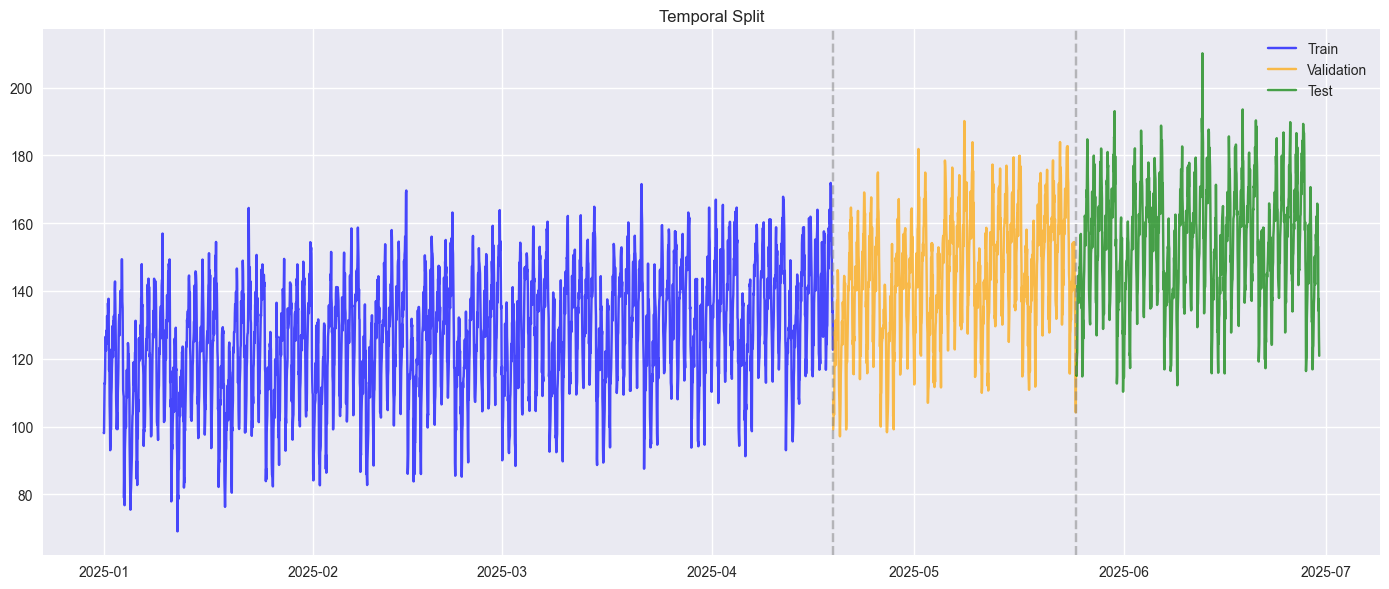

In [3]:
# Параметры сплита
n = len(df)
train_size = int(n * 0.6)
val_size = int(n * 0.2)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size+val_size].copy()
test_df = df.iloc[train_size+val_size:].copy()

# Формируем подробное описание сплита для отчета
split_description = f"Train: {train_df['date'].min()} - {train_df['date'].max()} | Val: {val_df['date'].min()} - {val_df['date'].max()} | Test: {test_df['date'].min()} - {test_df['date'].max()}"

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print(f"Test:  {len(test_df)} rows")

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], label='Test', color='green', alpha=0.7)
plt.axvline(x=train_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.title('Temporal Split')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

In [4]:
def create_features(df):
    df = df.copy()
    # ТРЕБОВАНИЕ: lag_1, lag_7, lag_14 (сдвиг на 1, 7 и 14 часов)
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    
    # ТРЕБОВАНИЕ: rolling_mean_7, rolling_std_7 (окно 7 часов)
    # Важно: shift(1) перед rolling, чтобы избежать утечки
    df['rolling_mean_7'] = df['target'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['target'].shift(1).rolling(window=7).std()
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

full_df = create_features(df)
full_df_clean = full_df.dropna().reset_index(drop=True)

# Пересчет границ сплита для очищенных данных
n_clean = len(full_df_clean)
train_end = int(n_clean * 0.6)
val_end = int(n_clean * 0.8)

full_train = full_df_clean.iloc[:train_end]
full_val = full_df_clean.iloc[train_end:val_end]
full_test = full_df_clean.iloc[val_end:]

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 
                'hour', 'day_of_week', 'is_weekend']
target_col = 'target'

X_train = full_train[feature_cols].values
y_train = full_train[target_col].values

X_val = full_val[feature_cols].values
y_val = full_val[target_col].values

X_test = full_test[feature_cols].values
y_test = full_test[target_col].values

print(f"Features created. Train shape: {X_train.shape}")

Features created. Train shape: (2583, 8)


In [5]:
# Инициализация скалера
scaler_features = StandardScaler()
scaler_target = StandardScaler()

# Явное обучение (fit) ТОЛЬКО на тренировочных данных
scaler_features.fit(X_train)
scaler_target.fit(y_train.reshape(-1, 1))

# Явное применение (transform) на валидации и тесте
X_train_scaled = scaler_features.transform(X_train)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

y_train_scaled = scaler_target.transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_target.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_target.transform(y_test.reshape(-1, 1)).flatten()

print("Scaling completed: fit on train, transform on val/test.")

Scaling completed: fit on train, transform on val/test.


In [6]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

# --- B1: Naive Last ---
pred_b1_val = full_val['lag_1'].values
mae_b1, rmse_b1, mape_b1 = calculate_metrics(y_val, pred_b1_val)
print(f"B1 (Naive Last) MAE: {mae_b1:.4f}")

# --- B2: Moving Average (Явная реализация) ---
# Прогноз равен скользящему среднему за последние 7 шагов
pred_b2_val = full_val['rolling_mean_7'].values
mae_b2, rmse_b2, mape_b2 = calculate_metrics(y_val, pred_b2_val)
print(f"B2 (Moving Average 7) MAE: {mae_b2:.4f}")

# --- B3: Ridge Regression ---
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)
pred_b3_val = model_ridge.predict(X_val_scaled)
mae_b3, rmse_b3, mape_b3 = calculate_metrics(y_val, pred_b3_val)
print(f"B3 (Ridge) MAE: {mae_b3:.4f}")

B1 (Naive Last) MAE: 6.4158
B2 (Moving Average 7) MAE: 12.6790
B3 (Ridge) MAE: 6.6871


Training GRU...
Epoch 10/30, Val Loss: 0.149034
Epoch 20/30, Val Loss: 0.143044
Epoch 30/30, Val Loss: 0.141054


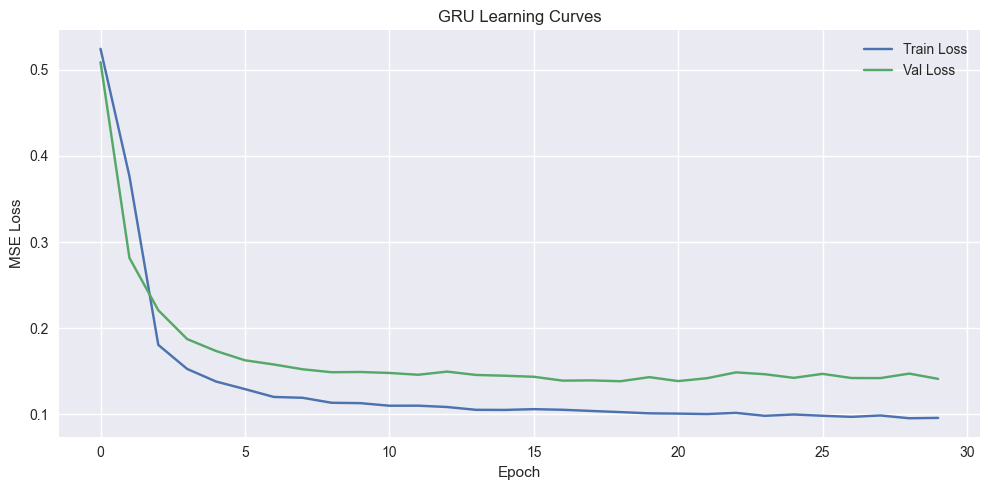

In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x = self.X[idx : idx + self.window_size]
        y_val = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y_val]).squeeze()

WINDOW_SIZE = 7 # Используем 7, чтобы соответствовать окну rolling
BATCH_SIZE = 64

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=48, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1] 
        return self.fc(last_hidden).squeeze(-1)

INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 48
NUM_LAYERS = 2
LEARNING_RATE = 0.001
EPOCHS = 30

model_gru = GRUForecaster(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)

best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'val_loss': []}

print("Training GRU...")
for epoch in range(EPOCHS):
    model_gru.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_gru(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model_gru.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model_gru(X_batch)
            loss = criterion(output, y_batch)
            val_losses.append(loss.item())
            
    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = model_gru.state_dict().copy()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Val Loss: {avg_val:.6f}")

model_gru.load_state_dict(best_model_state)
torch.save(best_model_state, "artifacts/best_gru.pt")

# График обучения
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('GRU Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

R1 (GRU) MAE: 5.2026
Best Model: R1


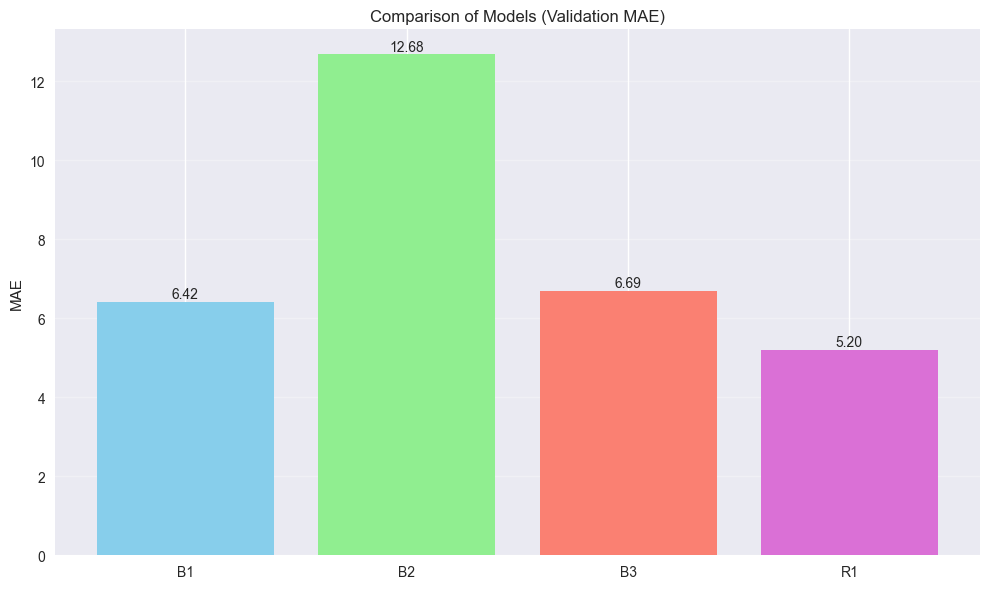

Final Test MAE: 8.0709
Results saved to artifacts/runs.csv


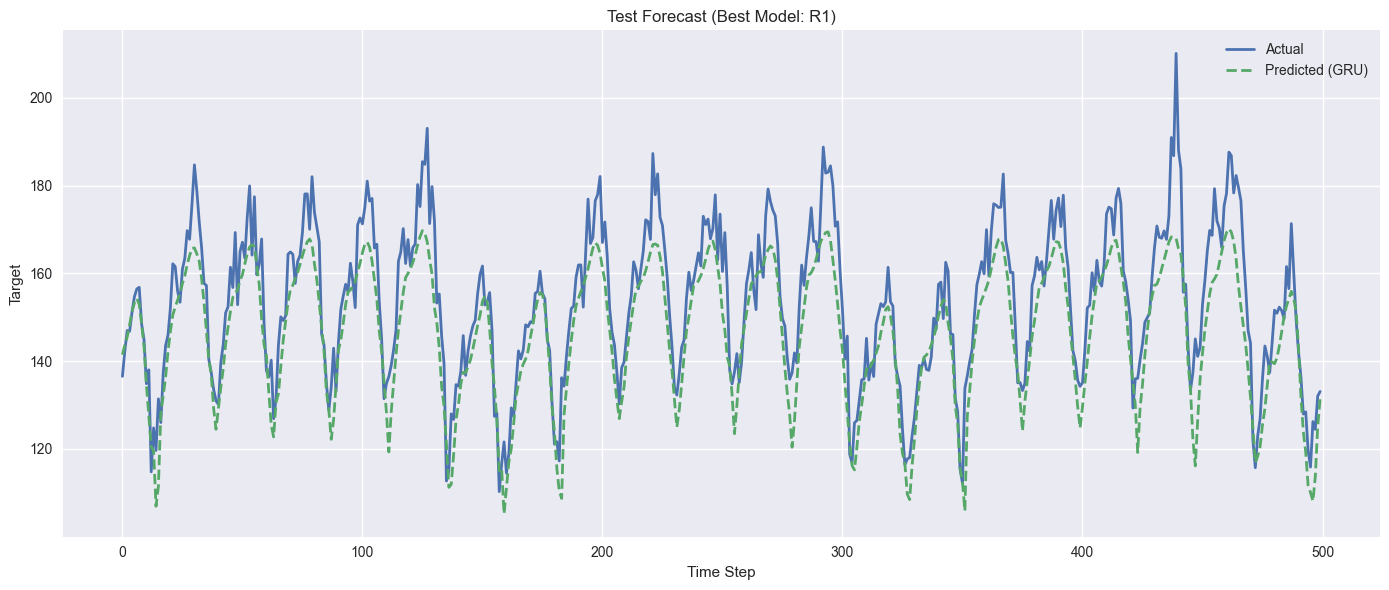

Config saved.


In [8]:
# Оценка GRU
model_gru.eval()
all_preds_val = []
all_targets_val = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model_gru(X_batch)
        all_preds_val.extend(output.cpu().numpy().flatten())
        all_targets_val.extend(y_batch.numpy().flatten())

pred_r1_val_scaled = np.array(all_preds_val)
target_val_scaled = np.array(all_targets_val)

pred_r1_val = scaler_target.inverse_transform(pred_r1_val_scaled.reshape(-1, 1)).flatten()
target_val_orig = scaler_target.inverse_transform(target_val_scaled.reshape(-1, 1)).flatten()

mae_r1, rmse_r1, mape_r1 = calculate_metrics(target_val_orig, pred_r1_val)
print(f"R1 (GRU) MAE: {mae_r1:.4f}")

results = {
    'B1': {'mae': mae_b1, 'rmse': rmse_b1, 'mape': mape_b1, 'name': 'Naive Last'},
    'B2': {'mae': mae_b2, 'rmse': rmse_b2, 'mape': mape_b2, 'name': 'Moving Avg'},
    'B3': {'mae': mae_b3, 'rmse': rmse_b3, 'mape': mape_b3, 'name': 'Ridge'},
    'R1': {'mae': mae_r1, 'rmse': rmse_r1, 'mape': mape_r1, 'name': 'GRU'}
}

best_exp_id = min(results, key=lambda x: results[x]['mae'])
print(f"Best Model: {best_exp_id}")

# График сравнения
plt.figure(figsize=(10, 6))
models = list(results.keys())
maes = [results[m]['mae'] for m in models]
bars = plt.bar(models, maes, color=['skyblue', 'lightgreen', 'salmon', 'orchid'])
plt.title('Comparison of Models (Validation MAE)')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

# Финальный тест
test_mae, test_rmse, test_mape = 0, 0, 0
plot_pred = None
plot_true = None

if best_exp_id == 'R1':
    all_preds_test = []
    all_targets_test = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model_gru(X_batch)
            all_preds_test.extend(output.cpu().numpy().flatten())
            all_targets_test.extend(y_batch.numpy().flatten())
    
    pred_test_scaled = np.array(all_preds_test)
    target_test_scaled = np.array(all_targets_test)
    
    plot_pred = scaler_target.inverse_transform(pred_test_scaled.reshape(-1, 1)).flatten()
    plot_true = scaler_target.inverse_transform(target_test_scaled.reshape(-1, 1)).flatten()
    test_mae, test_rmse, test_mape = calculate_metrics(plot_true, plot_pred)
    
elif best_exp_id == 'B3':
    pred_test = model_ridge.predict(X_test_scaled)
    plot_pred = pred_test
    plot_true = y_test
    test_mae, test_rmse, test_mape = calculate_metrics(y_test, pred_test)
else:
    col_map = {'B1': 'lag_1', 'B2': 'rolling_mean_7'}
    pred_test = full_test[col_map[best_exp_id]].values
    plot_pred = pred_test
    plot_true = full_test['target'].values
    test_mae, test_rmse, test_mape = calculate_metrics(full_test['target'].values, pred_test)

print(f"Final Test MAE: {test_mae:.4f}")

# Сохранение runs.csv (ИСПРАВЛЕНО: split_summary и lr)
runs_data = [
    {
        'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_description, 'window_size': 'N/A', 'horizon': 1, 'model_summary': 'Naive Last',
        'features_summary': 'lag_1', 'scaler': 'None', 'optimizer': 'N/A', 'lr': 1.0, 'epochs_trained': 0,
        'best_val_mae': mae_b1, 'best_val_rmse': rmse_b1, 'best_val_mape': mape_b1,
        'test_mae': test_mae if best_exp_id=='B1' else '', 'test_rmse': test_rmse if best_exp_id=='B1' else '', 'test_mape': test_mape if best_exp_id=='B1' else '', 'notes': 'Baseline'
    },
    {
        'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_description, 'window_size': 7, 'horizon': 1, 'model_summary': 'Moving Average',
        'features_summary': 'rolling_mean_7', 'scaler': 'None', 'optimizer': 'N/A', 'lr': 1.0, 'epochs_trained': 0,
        'best_val_mae': mae_b2, 'best_val_rmse': rmse_b2, 'best_val_mape': mape_b2,
        'test_mae': test_mae if best_exp_id=='B2' else '', 'test_rmse': test_rmse if best_exp_id=='B2' else '', 'test_mape': test_mape if best_exp_id=='B2' else '', 'notes': 'Baseline'
    },
    {
        'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_description, 'window_size': 'N/A', 'horizon': 1, 'model_summary': 'Ridge Regression',
        'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, calendar', 'scaler': 'Standard', 'optimizer': 'Closed Form', 'lr': 1.0, 'epochs_trained': 0,
        'best_val_mae': mae_b3, 'best_val_rmse': rmse_b3, 'best_val_mape': mape_b3,
        'test_mae': test_mae if best_exp_id=='B3' else '', 'test_rmse': test_rmse if best_exp_id=='B3' else '', 'test_mape': test_mape if best_exp_id=='B3' else '', 'notes': 'Linear Model'
    },
    {
        'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED,
        'split_summary': split_description, 'window_size': WINDOW_SIZE, 'horizon': 1, 'model_summary': f'GRU({HIDDEN_SIZE}, {NUM_LAYERS})',
        'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, calendar', 'scaler': 'Standard', 'optimizer': 'Adam', 'lr': LEARNING_RATE, 'epochs_trained': EPOCHS,
        'best_val_mae': mae_r1, 'best_val_rmse': rmse_r1, 'best_val_mape': mape_r1,
        'test_mae': test_mae if best_exp_id=='R1' else '', 'test_rmse': test_rmse if best_exp_id=='R1' else '', 'test_mape': test_mape if best_exp_id=='R1' else '', 'notes': 'Deep Learning'
    }
]

with open('artifacts/runs.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=runs_data[0].keys())
    writer.writeheader()
    writer.writerows(runs_data)
print("Results saved to artifacts/runs.csv")

# График прогноза
plt.figure(figsize=(14, 6))
plot_len = min(500, len(plot_true))
plt.plot(plot_true[:plot_len], label='Actual', linewidth=2)
plt.plot(plot_pred[:plot_len], label=f'Predicted ({results[best_exp_id]["name"]})', linestyle='--', linewidth=2)
plt.title(f'Test Forecast (Best Model: {best_exp_id})')
plt.xlabel('Time Step')
plt.ylabel('Target')
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

# Конфиг
config = {
    "window_size": WINDOW_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "seed": SEED,
    "input_features": feature_cols,
    "scaler": "StandardScaler"
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)
print("Config saved.")